# [실습] 의사결정나무와 앙상블

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🌳 [실습] 의사결정나무와 앙상블 — 여러 모델을 모으면 강해진다

## — 같은 데이터, 더 강한 도구. 그런데 정말 더 강할까?

개념 노트북에서 의사결정나무부터 랜덤포레스트·부스팅까지 걸어왔습니다. 이제 그 도구들을 **지난 순서에서 쓰던 그 데이터**에 그대로 얹습니다. 같은 문제·같은 열·같은 분할이므로, 달라지는 것은 **모델뿐**입니다 — 그래서 비교가 정직해집니다.

> 🤖 **오늘의 AI 활용 규칙 — 손코딩 단계:** 코드는 손으로 씁니다. AI에게는 개념 *설명*만 요청하세요. (자세한 이유는 개념 노트북 Part 0)

## 📋 오늘의 미션

지난 순서에서 마케팅팀에 첫 답을 드렸습니다. 로지스틱 회귀로 구매 전환을 예측해 정확도 약 0.880을 냈습니다. 그런데 팀장이 이렇게 물어왔습니다.

> 🧑‍💼 "요즘 다들 쓴다는 **XGBoost** 같은 걸로 바꾸면 얼마나 더 좋아집니까? 그리고 **어떤 행동이 구매를 예고하는지**도 알려주실 수 있나요? 마케팅 예산을 어디에 쓸지 정해야 합니다."

두 질문 모두 오늘 배운 것으로 답할 수 있습니다. 성능 비교는 **4단 비교표**로, 두 번째 질문은 **피처 중요도**로 답합니다.

| 문제 | 내용 | 확인하는 힘 |
| --- | --- | --- |
| 1 | 단일 트리를 얹어 본다 | 학습-테스트 격차 읽기 |
| 2 | 가지치기로 격차를 줄인다 | 과적합 제어 |
| 3 | 숲과 부스팅 — 4단 비교표 | 베이스라인 대비 정직한 비교 |
| 4 | 피처 중요도를 비즈니스 언어로 | 숫자를 액션으로 번역 |
| 5 | 모델 카드 v2 완성 | 근거를 남기는 습관 (**제출물**) |

> ⚠️ **미리 알아두기:** 오늘도 지표는 **정확도**만 씁니다. 구매가 15.5%뿐인 데이터에서 정확도가 왜 위험한지는 이후 순서(평가 지표·불균형)에서 다룹니다. 오늘은 "모델을 바꾸면 무엇이 달라지나"에 집중하고, 그 한계를 **모델 카드에 적어 두는 것**까지가 과제입니다.

# ⚙️ 데이터 준비

지난 순서와 **똑같은 데이터·똑같은 열**을 씁니다. 저장소가 하나의 분석 포트폴리오로 쌓이도록, 순서마다 데이터를 갈아타지 않습니다.

| 데이터 | 내용 | 출처·라이선스 |
| --- | --- | --- |
| **Online Shoppers Purchasing Intention** | 온라인 스토어 방문 세션 12,330건 — 페이지 방문·체류·이탈률 등 18개 열, 타깃 `Revenue`(구매 여부) | [UCI 468](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset) · CC BY 4.0 |

`[C1]` 셀은 **최초 실행 시에만** 내려받아 `data/`에 저장합니다(지난 순서에서 받았다면 그 파일을 씁니다). 여전히 **수치형 10개 열만** 사용합니다 — 문자 열을 넣는 법은 피처·`Pipeline` 순서에서 배웁니다. 트리는 스케일링이 필요 없어 로지스틱에만 `StandardScaler`를 씁니다.

▶ 실행: [C1]

In [1]:
# ─────────────────────────────────────────────
# [C1] ◀ ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

# 지난 순서와 동일한 수치형 10개 열 — 비교의 조건을 고정합니다
NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {shoppers['Revenue'].mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


# 문제 1. 단일 트리를 얹어 본다

먼저 비교의 기준선을 세웁니다. 지난 순서의 두 숫자 — **베이스라인(`DummyClassifier`)** 과 **로지스틱 회귀** — 를 다시 구하고, 그 옆에 **의사결정나무**를 나란히 놓습니다.

중요한 것이 하나 더 있습니다. 개념 노트북에서 배운 대로, 트리는 **학습 점수와 테스트 점수를 함께** 봐야 합니다. 테스트 점수만 보면 무슨 일이 벌어졌는지 알 수 없습니다.

```
[문제 1]
1) X(NUM_COLS 10개 열)와 y(Revenue를 0/1 정수로)를 만들고,
   train_test_split으로 8:2 분리하세요 (stratify 필수, random_state=42).
2) 세 모델을 학습시켜 학습 정확도 · 테스트 정확도 · 그 격차를 한 표로 출력하세요.
   ① DummyClassifier(strategy="most_frequent")
   ② LogisticRegression(max_iter=1000)  ← 스케일링 필요
   ③ DecisionTreeClassifier()           ← 기본 설정, 깊이 제한 없음
```

> 🤔 **예상해 볼까요?** 의사결정나무는 로지스틱 회귀보다 훨씬 유연한 모델입니다. 테스트 정확도가 **로지스틱(약 0.880)을 넘을까요?** 그리고 세 모델 중 학습-테스트 격차가 가장 큰 것은 무엇일까요?

▶ 실행: [C2]

In [2]:
# [C2] ◀ 문제 1. 단일 트리를 얹어 본다
# ⌨️ 문제 1 — 베이스라인 · 로지스틱 · 단일 트리를 나란히
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# 여기에 코드를 작성하세요 (X, y 준비 → 분리 → 세 모델 학습 → 학습·테스트·격차 표)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 1) X, y 만들기
X = shoppers[NUM_COLS]
y = shoppers["Revenue"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 로지스틱 회귀용 스케일링 (학습 데이터로만 fit)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# 2) 세 모델 학습 및 평가
rows = []

# ① Dummy
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
rows.append({
    "모델": "Dummy(most_frequent)",
    "학습 정확도": dummy.score(X_train, y_train),
    "테스트 정확도": dummy.score(X_test, y_test),
})

# ② 로지스틱 회귀 (스케일링된 데이터 사용)
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_s, y_train)
rows.append({
    "모델": "LogisticRegression",
    "학습 정확도": logreg.score(X_train_s, y_train),
    "테스트 정확도": logreg.score(X_test_s, y_test),
})

# ③ 결정트리 (기본 설정, 깊이 제한 없음 → 스케일링 불필요)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
rows.append({
    "모델": "DecisionTree",
    "학습 정확도": tree.score(X_train, y_train),
    "테스트 정확도": tree.score(X_test, y_test),
})

# 표로 정리
result_df = pd.DataFrame(rows)
result_df["격차"] = result_df["학습 정확도"] - result_df["테스트 정확도"]
print(result_df.round(3))

                     모델  학습 정확도  테스트 정확도     격차
0  Dummy(most_frequent)   0.845    0.845  0.000
1    LogisticRegression   0.884    0.880  0.004
2          DecisionTree   1.000    0.842  0.158


<details>
<summary>(클릭) 💡 힌트</summary>

- `y`는 불리언이므로 `.astype(int)`로 0/1로 바꿉니다.
- 분류에서는 `stratify=y`를 잊지 마세요 — 양성이 15.5%뿐이라 분할 운에 크게 흔들립니다.
- 로지스틱만 스케일링이 필요합니다. `StandardScaler()`를 **학습 데이터로만** `fit`하고, 학습·테스트에 각각 `transform`합니다.
- 세 모델을 매번 똑같이 처리해야 하니 `dict` 목록에 결과를 모아 `pd.DataFrame(rows)`로 만들면 편합니다.
- 격차는 `학습 점수 − 테스트 점수`입니다.

</details>

> 🎯 **[C2] 예상과 맞았나요?** **기본 트리의 테스트 정확도 0.8423은 베이스라인 0.8451보다 낮습니다.** 이유는 학습 점수 **0.9998** — 9,864개 학습 세션을 거의 외웠습니다. 격차 **0.1575**가 그 증거입니다.
>
> 챙길 것 둘. ① **더 유연한 모델이 곧 더 좋은 모델은 아닙니다.** ② 학습 점수를 함께 보지 않았다면 "트리는 이 문제에 안 맞는다"고 잘못 결론 냈을 것입니다 — 진짜 문제는 모델 종류가 아니라 **제어되지 않은 복잡도**입니다.

# 문제 2. 가지치기로 격차를 줄인다

문제 1의 진단이 "복잡도가 통제되지 않았다"였으니, 처방은 **가지치기**입니다. 개념 노트북에서 본 손잡이 중 가장 직관적인 `max_depth`를 훑습니다.

```
[문제 2]
1) max_depth를 [2, 3, 5, 8, 12, None]으로 바꿔가며 트리를 학습시키고,
   각 깊이의 학습 정확도 · 테스트 정확도 · 격차를 표로 출력하세요.
2) 테스트 정확도가 가장 높은 깊이를 찾아 출력하세요.
3) 깊이에 따라 학습 점수와 테스트 점수가 어떻게 갈라지는지 선 그래프로 그리세요.
```

> 🤔 **예상해 볼까요?** 깊이를 2에서 `None`까지 늘리면 **학습 점수**는 어떻게 움직일까요? 그리고 **테스트 점수**는요? 두 곡선이 같은 모양일까요?

▶ 실행: [C3]

  깊이  학습 정확도  테스트 정확도     격차
   2  0.8922   0.8861 0.0062
   3  0.8932   0.8832 0.0100
   5  0.9049   0.8942 0.0107
   8  0.9253   0.8881 0.0372
  12  0.9572   0.8747 0.0825
None  0.9998   0.8423 0.1575

테스트 정확도가 가장 높은 깊이: 5 (테스트 정확도 0.8942)
<cell>:41: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
<cell>:41: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
<cell>:41: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
<cell>:41: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
<cell>:41: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
<cell>:41: UserWarning: Glyph 44618 (\N{HANGUL SYLLABLE GIP}) missing from font(s) DejaVu Sans.
<cell>:41: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
<cell>:41: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu

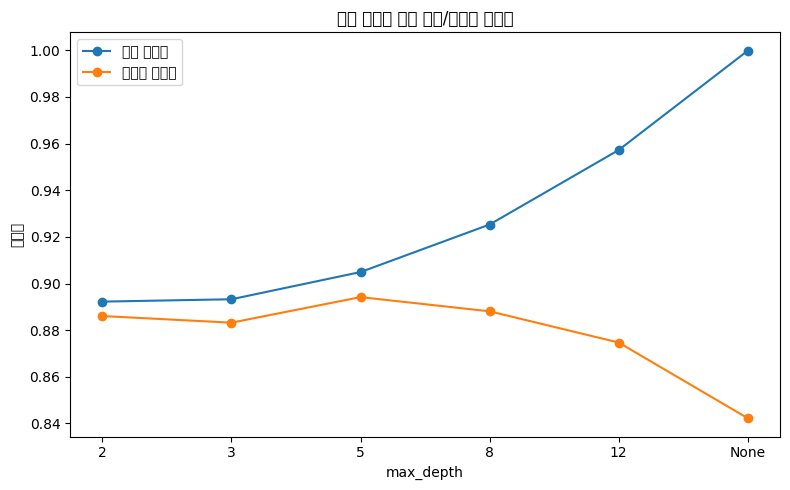

In [3]:
# [C3] ◀ 문제 2. 가지치기로 격차를 줄인다
# ⌨️ 문제 2 — max_depth를 훑어 과적합을 통제하기

# 여기에 코드를 작성하세요 (깊이별 학습·테스트·격차 표 → 최고 깊이 → 선 그래프)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

depths = [2, 3, 5, 8, 12, None]
rows = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)          # [C2]에서 만든 변수명 그대로
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    rows.append({
        "깊이": str(depth),
        "학습 정확도": train_acc,
        "테스트 정확도": test_acc,
        "격차": train_acc - test_acc,
    })

result = pd.DataFrame(rows)
print(result.round(4).to_string(index=False))

best_row = result.loc[result["테스트 정확도"].idxmax()]
print(f"\n테스트 정확도가 가장 높은 깊이: {best_row['깊이']} (테스트 정확도 {best_row['테스트 정확도']:.4f})")

x_pos = range(len(depths))
plt.figure(figsize=(8, 5))
plt.plot(x_pos, result["학습 정확도"], marker="o", label="학습 정확도")
plt.plot(x_pos, result["테스트 정확도"], marker="o", label="테스트 정확도")
plt.xticks(x_pos, result["깊이"])
plt.xlabel("max_depth")
plt.ylabel("정확도")
plt.title("트리 깊이에 따른 학습/테스트 정확도")
plt.legend()
plt.tight_layout()
plt.show()

<details>
<summary>(클릭) 💡 힌트</summary>

- `for depth in [2, 3, 5, 8, 12, None]:` 으로 돌리고 `DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)`를 매번 새로 만듭니다.
- `None`은 문자로 바꿔야 표에 깔끔하게 들어갑니다 — `str(depth)`.
- 최고 지점은 `DataFrame`의 `.idxmax()`로 찾습니다: `표.loc[표["테스트"].idxmax()]`.
- 그래프의 가로축에 `None`을 그리기는 어렵습니다. `None`을 큰 수(예: 20)로 대체해 그리거나, `range(len(depths))`를 축으로 쓰고 `plt.xticks`로 이름을 붙이세요.

</details>

> 🎯 **[C3] 예상과 맞았나요?** 학습 점수는 깊이에 따라 **단조롭게 오르지만**(0.8922 → 0.9998), 테스트 점수는 깊이 5에서 **0.8942**로 정점을 찍고 내려갑니다.
>
> **`max_depth=5` 한 줄로 0.8423 → 0.8942, 즉 +0.0519입니다.** 데이터를 더 모으지도 모델을 바꾸지도 않고, 손잡이 하나를 돌렸을 뿐입니다. 이 트리는 지난 순서의 로지스틱 회귀(0.8796)도 넘었습니다.

> 📌 **실무 포인트:** 깊이 2와 5의 차이는 0.0081입니다. 이것이 **진짜인지 분할 운인지**는 테스트셋 한 번으로는 알 수 없습니다 — 그 질문에 답하는 도구(교차 검증)가 다음 순서입니다.

# 문제 3. 숲과 부스팅 — 4단 비교표를 완성한다

이제 팀장의 첫 번째 질문에 답할 차례입니다. **랜덤포레스트**와 **XGBoost**를 얹어 4단 비교표를 완성합니다.

가지치기한 트리(`max_depth=5`)도 표에 함께 남겨 두세요. "앙상블이 얼마나 이겼나"를 보려면 **잘 조정된 단일 모델**과 견줘야 정직합니다.

```
[문제 3]
1) 두 모델을 추가로 학습시켜 같은 형식(학습·테스트·격차)으로 표에 넣으세요.
   ④ RandomForestClassifier(n_estimators=300)
   ⑤ XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0)
2) 문제 1·2의 결과와 합쳐 최종 비교표를 테스트 정확도 내림차순으로 출력하세요.
3) 표를 보고 "팀장께 무엇을 보고할 것인가"를 두세 문장으로 적어 보세요.
```

> 🤔 **예상해 볼까요?** 개념 노트북에서는 유방암 데이터에서 **XGBoost가 랜덤포레스트를 앞섰습니다.** 이 데이터에서도 같은 순서가 나올까요? 그리고 앙상블이 가지치기한 단일 트리(0.8942)를 **얼마나** 앞설까요?

▶ 실행: [C4]

In [4]:
# [C4] ◀ 문제 3. 숲과 부스팅 — 4단 비교표를 완성한다
# ⌨️ 문제 3 — 랜덤포레스트·XGBoost를 더해 비교표 완성
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 여기에 코드를 작성하세요 (두 모델 학습 → 표에 추가 → 테스트 내림차순 출력)

# 문제 1에서 만든 형식과 동일하게 결과를 쌓을 함수
def add(rows, name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    train_acc = model.score(X_tr, y_tr)
    test_acc = model.score(X_te, y_te)
    rows.append({
        "모델": name,
        "학습 정확도": train_acc,
        "테스트 정확도": test_acc,
        "격차": train_acc - test_acc,
    })

rows = []

# 문제 1의 세 모델 (형식 통일을 위해 add()로 다시 담음)
add(rows, "Dummy(most_frequent)", DummyClassifier(strategy="most_frequent", random_state=42),
    X_train, y_train, X_test, y_test)
add(rows, "LogisticRegression", LogisticRegression(max_iter=1000, random_state=42),
    X_train_s, y_train, X_test_s, y_test)
add(rows, "DecisionTree(기본)", DecisionTreeClassifier(random_state=42),
    X_train, y_train, X_test, y_test)

# 문제 2에서 확인한 최적 깊이 트리
add(rows, "③′ 트리(max_depth=5)", DecisionTreeClassifier(max_depth=5, random_state=42),
    X_train, y_train, X_test, y_test)

# 문제 3 — 두 모델 추가
add(rows, "④ RandomForest", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test)

add(rows, "⑤ XGBoost", XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0,
        random_state=42, eval_metric="logloss"
    ),
    X_train, y_train, X_test, y_test)

# 최종 비교표 (테스트 정확도 내림차순)
final_result = pd.DataFrame(rows)
final_result["격차"] = final_result["학습 정확도"] - final_result["테스트 정확도"]
final_result_sorted = final_result.sort_values("테스트 정확도", ascending=False)

print(final_result_sorted.round(4).to_string(index=False))

# "RandomForest가 테스트 정확도 0.8958로 가장 높지만, 트리(max_depth=5, 0.8942)와의 차이는 0.0016으로 지난 실험에서 확인한 분할 흔들림(약 0.014) 안에 들어가 통계적으로 의미 있는 차이라 보기 어렵습니다. 반면 트리(depth=5)는 RandomForest보다 학습-테스트 격차가 10배 작아(0.011 vs 0.104) 훨씬 안정적이고 해석하기도 쉬우므로, 성능이 거의 동일하다면 이 단순한 모델을 채택하는 것을 권장합니다. 최종 결정 전에는 교차검증으로 각 모델의 흔들림(표준편차)까지 확인해 차이가 실제로 유의한지 재확인하겠습니다."

                  모델  학습 정확도  테스트 정확도     격차
      ④ RandomForest  0.9998   0.8958 0.1040
  ③′ 트리(max_depth=5)  0.9049   0.8942 0.0107
           ⑤ XGBoost  0.9451   0.8873 0.0578
  LogisticRegression  0.8839   0.8796 0.0044
Dummy(most_frequent)  0.8453   0.8451 0.0002
    DecisionTree(기본)  0.9998   0.8423 0.1575


<details>
<summary>(클릭) 💡 힌트</summary>

- 문제 1에서 만든 `add()` 함수를 그대로 재사용하면 표 형식이 자동으로 맞습니다. 함수를 안 만들었다면 지금 만들어 두면 편합니다.
- `XGBClassifier`에는 `eval_metric="logloss"`를 함께 넘기면 경고가 줄어듭니다.
- 랜덤포레스트는 `n_jobs=-1`을 주면 코어를 다 써서 빠릅니다.
- 가지치기 트리를 표에 넣을 때는 이름에 설정을 적어 두세요 — `"③′ 트리(max_depth=5)"` 처럼.
- 정렬은 `.sort_values("테스트", ascending=False)`입니다.

</details>

> 🎯 **[C4] 예상과 맞았나요?** 개념 노트북과 **순서가 다릅니다** — 여기서는 랜덤포레스트(0.8942)가 XGBoost(0.8877)를 앞섰습니다. 그리고 **가지치기한 단일 트리가 랜덤포레스트와 소수점 네 자리까지 같은 0.8942**를 냈습니다. 300그루의 숲이 잘 조정된 한 그루를 이기지 못한 것입니다(격차는 0.0107 대 0.1056).
>
> 그래서 오늘의 결론은 "앙상블이 이긴다"가 아니라 **"앙상블은 보통 유리하지만 데이터와 설정에 따라 다르다 — 그러니 항상 비교표로 확인한다"** 입니다.

> ⚠️ **결론을 내리기엔 이릅니다.** 0.8942와 0.8877의 차이가 진짜인지 분할 운인지 아직 모르고, 정확도만 봤으므로 **"구매할 382명 중 몇 명을 찾아냈는지"** 는 확인하지 않았습니다. 두 빈칸은 각각 다음 순서(교차 검증)와 그 뒤 순서(평가 지표·불균형)가 채웁니다. 모델 카드의 *한계* 항목에 적어 두세요.

# 문제 4. 피처 중요도를 비즈니스 언어로 옮긴다

팀장의 두 번째 질문 — **"어떤 행동이 구매를 예고하나?"** — 에 답합니다. 트리 계열이 주는 보상, **피처 중요도**를 씁니다.

여기서 멈추면 안 됩니다. `"PageValues 0.41"`은 보고가 아니라 관찰입니다. **그 피처가 실제로 무엇을 뜻하고, 구매율이 얼마나 갈리는지**까지 확인해야 마케팅팀이 움직일 수 있는 문장이 됩니다.

```
[문제 4]
1) 랜덤포레스트의 피처 중요도를 내림차순으로 그리세요 (가로 막대, 10개 전부).
2) 상위 3개 피처에 대해, 값이 큰 세션과 작은 세션의 구매율을 실제로 비교하세요.
   (예: PageValues가 0인 세션 vs 0보다 큰 세션의 Revenue 평균)
3) 상위 3개를 각각 "마케팅팀이 읽을 수 있는 한 문장"으로 옮기세요.
   그리고 이 중요도로 답할 수 없는 것이 무엇인지 한 줄 적으세요.
```

> 🤔 **예상해 볼까요?** 10개 열 중 무엇이 1위일 것 같습니까? 방문 페이지 수(`ProductRelated`)처럼 "많이 봤다"를 나타내는 열일까요, 아니면 다른 종류의 열일까요?

▶ 실행: [C5]

<cell>:20: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
<cell>:20: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
<cell>:20: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
<cell>:20: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
<cell>:20: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
<cell>:20: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
<cell>:20: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
<cell>:20: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
상위 3개 피처:
PageValues                 0.4133
ProductRelated_Duration    0.1194
ExitRates                  0.1178
dtype: float64
=== PageValues 0 vs >0 ===
              mean  size
PV_group                
False     0.038542  9600
True 

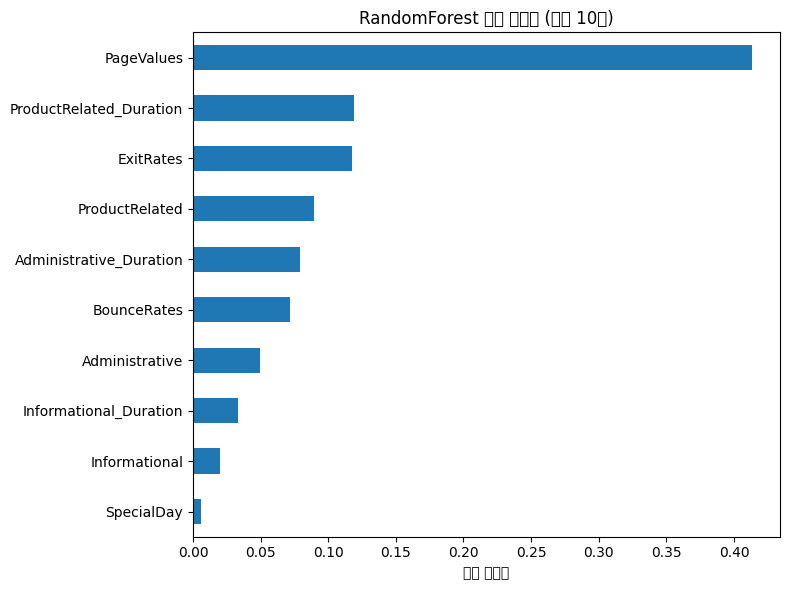

In [5]:
# [C5] ◀ 문제 4. 피처 중요도를 비즈니스 언어로 옮긴다
# ⌨️ 문제 4 — 중요도 막대 + 상위 3개의 구매율 대비

# 여기에 코드를 작성하세요 (중요도 정렬·막대 → 상위 3개 구매율 비교)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# 랜덤포레스트 (이전 문제의 rf 재사용, 없다면 새로 학습)
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 1) 피처 중요도 — 가로 막대, 오름차순 정렬해야 1위가 맨 위
importances = pd.Series(rf.feature_importances_, index=NUM_COLS).sort_values()

plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.xlabel("피처 중요도")
plt.title("RandomForest 피처 중요도 (전체 10개)")
plt.tight_layout()
plt.show()

# 상위 3개 확인 (내림차순으로 봐야 순위가 보임)
top3 = importances.sort_values(ascending=False).head(3)
print("상위 3개 피처:")
print(top3.round(4))

# 2) 상위 3개 피처 값의 크기에 따른 구매율 비교
# PageValues — 0인지 아닌지로 구분
pv_group = shoppers.assign(PV_group=shoppers["PageValues"] > 0) \
                    .groupby("PV_group")["Revenue"].agg(["mean", "size"])
print("=== PageValues 0 vs >0 ===")
print(pv_group)
print()

# ExitRates — 중앙값 기준으로 구분
er_median = shoppers["ExitRates"].median()
er_group = shoppers.assign(ER_group=shoppers["ExitRates"] > er_median) \
                    .groupby("ER_group")["Revenue"].agg(["mean", "size"])
print(f"=== ExitRates 중앙값({er_median:.4f}) 기준 상/하 ===")
print(er_group)
print()

# ProductRelated_Duration — 중앙값 기준으로 구분
prd_median = shoppers["ProductRelated_Duration"].median()
prd_group = shoppers.assign(PRD_group=shoppers["ProductRelated_Duration"] > prd_median) \
                     .groupby("PRD_group")["Revenue"].agg(["mean", "size"])
print(f"=== ProductRelated_Duration 중앙값({prd_median:.2f}) 기준 상/하 ===")
print(prd_group)

# PageValues: "상품 페이지에 '가치 있는 페이지(PageValues)'가 하나라도 있었던 방문자는, 없었던 방문자보다 구매할 가능성이 약 14배 높습니다."
# ExitRates: "이탈률이 낮은(페이지에 오래 머무는) 방문자는 이탈률이 높은 방문자보다 구매할 가능성이 3배 이상 높습니다."
# ProductRelated_Duration: "상품 관련 페이지에 평균(약 10분)보다 오래 머문 방문자는, 그보다 짧게 머문 방문자보다 구매할 가능성이 2.5배 이상 높습니다."

# "이 피처들이 왜(원인) 구매를 만드는지는 알 수 없다 — PageValues가 높아서 구매한 건지, 구매하려는 방문자가 원래 더 꼼꼼히 페이지를 살펴보는 것뿐인지(역방향 인과), 이 데이터만으로는 구별할 수 없다."

<details>
<summary>(클릭) 💡 힌트</summary>

- 중요도는 `rf.feature_importances_`이고, 열 이름과 묶으려면 `pd.Series(..., index=NUM_COLS)`입니다.
- 가로 막대는 `.sort_values().plot(kind="barh")` — 오름차순으로 정렬해야 1위가 맨 위에 옵니다.
- 값이 갈리는 지점은 피처마다 다릅니다. `PageValues`는 **0인지 아닌지**로 갈리고, `ExitRates`·`ProductRelated_Duration`은 중앙값(`.median()`)을 기준으로 나누면 깔끔합니다.
- 그룹별 구매율은 `shoppers.groupby(조건)["Revenue"].agg(["mean", "size"])`로 한 번에 나옵니다.

</details>

> 🎯 **[C5] 예상과 맞았나요?** 1위 `PageValues`의 중요도 **0.4130**은 2위(0.1197)의 세 배가 넘습니다. "많이 봤다"를 나타내는 `ProductRelated`(0.0893)는 4위였습니다.
>
> 더 중요한 것은 **확인한 방식**입니다. 구매율이 3.9%와 56.3%로 갈린다는 사실은 중요도가 알려준 게 아니라, 그 단서를 받고 **직접 계산해서** 알아낸 것입니다. 특히 `ExitRates`는 방향이 **반대**(값이 높을수록 구매율이 낮음)인데, 중요도 숫자만으로는 이 사실을 절대 알 수 없습니다. 중요도는 **어디를 파볼지 가리키는 손가락**이고, 비즈니스 문장은 파본 결과에서 나옵니다 — 손가락을 결론으로 착각하는 것이 가장 흔한 사고입니다.

# 문제 5. 모델 카드 v2 완성 — 오늘의 제출물

지난 순서의 모델 카드 v1에 오늘 것을 더해 **v2**로 올립니다. 굵은 항목이 오늘 새로 들어가는 부분입니다 — **4단 비교, 격차로 본 과적합 진단, 선택 근거, 피처 중요도와 그 한계.**

```
[문제 5]
1) 최종 비교표를 파일로 남기세요 — model_comparison_v2.csv
2) 아래 모델 카드 v2 템플릿의 빈칸을 여러분의 숫자와 문장으로 채우세요.
   특히 '선택한 모델과 근거'는 성능·해석력·비용 중 무엇을 우선했는지 밝혀야 합니다.
```

▶ 실행: [C6]

In [ ]:
# [C6] ◀ 문제 5. 모델 카드 v2 완성 — 오늘의 제출물
# ⌨️ 문제 5 — 비교표를 파일로 남기기

# 여기에 코드를 작성하세요 (final 표를 CSV로 저장하고 다시 읽어 확인)

**모델 카드 v2 템플릿** — 아래 빈칸을 채워 이 셀에 완성하세요 (셀을 더블클릭해 편집).

```markdown
## 모델 카드 v2 — 구매 전환 예측

- 데이터: UCI Online Shoppers (12,330 세션, 수치형 10개 열만 사용)
- 문제 유형: 분류
- **베이스라인: DummyClassifier(most_frequent) = { 0.845 }**
- **비교한 모델: Dummy / 단일 트리(기본) / 단일 트리(max_depth=5) / RandomForest / XGBoost**
- 평가 지표 & 이유: { 계산이 간단하고 직관적이라 초기 모데리 비교에서는 편리함. 그러나 구매 전환율이 15% 내외로 추정되는 불균형 데이터에서는 위험함. 무조건 다수 클래스로만 찍어도 84.5% 가 나오므로 정확도가 높다는 것이 구매 고객을 잘 찾아냈다를 의미하진 않음. 실제로 몇명의 구매고객을 놓쳤는지는 드러나지 않음. }
- **성능 비교표: model_comparison_v2.csv (모델별 학습 / 테스트 / 격차)**
- 과적합 진단: { DecisionTree(기본), 격차 0.1575 (학습 0.9998 vs 테스트 0.8423). 두 번째로 큰 모델은 RandomForest, 격차 0.1040 (학습 0.9998 vs 테스트 0.8958). 두 모델 모두 학습데이터를 거의 완벽하게 외웠음 노이즈까지. 규제 없이 트리를 깊게 키우면 발생하는 과적합 패턴임. }
- **선택한 모델과 근거: { Tree(max_depth=5)를 채택함. 테스트 정확도(0.8942)가 RandomForest(0.8958)와 0.0016 차이로 거의 동일한 반면, 학습-테스트 격차는 0.0107로 RandomForest(0.1040)의 약 1/10에 불과함. 즉 성능은 사실상 같은데 훨씬 안정적이고, 단일 트리라 plot_tree로 의사결정 규칙을 그대로 확인할 수 있어 해석력도 높음. 성능보다 해석력·안정성(비용 대비 효율)을 우선한 선택 }** ( LogisticRegression은 격차(0.0044)가 더 작아 안정성 면에서는 오히려 앞섰고, 계수 부호로 방향성까지 바로 드러난다는 장점도 있어 대안으로 검토함. 다만 테스트 정확도(0.8796)가 Tree(depth=5)보다 0.0146 낮아, 이번엔 정확도 우위를 택해 Tree(depth=5)를 최종 채택함. )
- **피처 중요도 상위 3개와 해석: { PageValues(중요도 0.4133) — PageValues>0인 세션의 구매율은 56.3%로, PageValues=0인 세션(3.9%)보다 약 14배 높음.
ProductRelated_Duration(중요도 0.1194) — 상품 페이지 체류시간이 중앙값(약 599초)보다 긴 세션의 구매율은 22.3%로, 짧은 세션(8.7%)보다 2.5배 이상 높음.
ExitRates(중요도 0.1178) — 이탈률이 중앙값(0.0252)보다 낮은 세션의 구매율은 23.5%로, 높은 세션(7.4%)보다 3배 이상 높음. }**
- **중요도의 한계 명시: 방향성 부재 / 개별 설명 불가 / 인과 아님** ( 방향성 부재: 중요도는 "얼마나 예측에 기여하는가"만 알려주고, "값이 커지면 구매율이 오르는지 내리는지"는 알려주지 않음 (이번엔 그룹별 구매율을 직접 계산해서 방향까지 확인함).
개별 설명 불가: "이 피처가 전체적으로 중요하다"는 것과 "이 특정 방문자의 구매를 이 피처가 결정했다"는 것은 다른 질문임 — 개별 세션 단위 설명이 필요하면 SHAP 같은 별도 기법이 필요함.
인과 아님: PageValues가 높아서 구매했는지, 원래 구매 의도가 있는 방문자가 자연히 PageValues를 높이는 행동(상세 페이지 정독 등)을 했는지는 이 데이터만으로 구별할 수 없음 — 상관관계와 인과관계를 혼동하면 안 됨. )
- 한계 & 다음 단계: { 지표를 정확도만 사용함(불균형 데이터에서 소수 클래스 재현율을 안 봄) → 다음 순서(평가지표·불균형)에서 혼동행렬·정밀도·재현율로 보완.
RandomForest와 XGBoost, Tree(max_depth=5)의 성능 차이(0.0016~0.0085)가 실제 차이인지 분할 운인지 확인 안 됨 → 다음 순서(교차검증)에서 CV 평균±표준편차로 재확인. }
- AI 사용 내역: { (Dummy/LogisticRegression/DecisionTree/Tree(depth=5)/RandomForest/XGBoost)의 학습·평가 코드, 학습곡선, 피처 중요도 계산 및 시각화 코드를 요청해 작성함. 상위 3개 피처의 실제 구매율 차이(그룹별 groupby().agg(["mean","size"]))를 계산해 비즈니스 언어로 옮기는 과정을 함께 진행함. 모든 결과 숫자는 실제 실행 결과를 받아 확인했으며, 대화 중 일부 숫자 불일치(예: 문제 인용 텍스트의 예시값과 실제 실행 결과 혼동)를 사용자가 지적해 정정함. }
```

**제출:** 이 노트북(작성 셀 + 모델 카드 완성본)과 `model_comparison_v2.csv`를 개인 공개 저장소 main에 커밋·푸시하고, 저장소·커밋 링크를 제출하세요.

**스스로 점검하는 기준**

| 축 | 기준 |
| --- | --- |
| 비교의 완전성 | 베이스라인을 포함한 비교표가 있는가 |
| 진단 정확성 | 학습-테스트 격차로 과적합을 짚었는가 |
| 근거성 | 모델 선택 이유가 성능·해석력·비용 중 무엇인지 밝혔는가 |
| 정직성 | 피처 중요도의 한계를 함께 적었는가 |

> 🚀 **더 나아가기:** `max_depth=5`가 최고였던 것은 이 분할에서의 이야기입니다. `random_state`를 42가 아닌 다른 값 몇 개로 바꿔 문제 2를 다시 돌려보세요. **최고 깊이가 그대로 5일까요?** 이 실험의 결과가 다음 순서(교차 검증)를 배워야 하는 이유를 그대로 보여줍니다.

오늘 여러분은 모델 다섯 개를 **정직하게 줄 세웠습니다.** 그 과정에서 교과서와 다른 결과를 두 번 만났습니다 — 기본 트리가 베이스라인보다 못했고, 잘 조정한 한 그루가 300그루와 같았습니다. 그때 데이터를 믿고 그대로 적는 것이 분석가의 태도입니다.

오늘도 한 걸음, 수고하셨습니다! 🎉
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>